# GameTheory-06g — Équilibres de jeux-programmes fondés sur la simulation

[← GameTheory-06f : preuves bornées](GameTheory-06f-Bounded-Proofs-Reasoning-Costs.ipynb) · [Série GameTheory](README.md)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

- expliquer pourquoi un programme fondé sur la **simulation** traite de la même façon deux adversaires au comportement identique, contrairement à une inspection syntaxique fragile ;
- construire un analogue fini et terminant d'un agent de type `εGroundedπBot` ;
- comparer empiriquement preuve bornée et simulation sur un Dilemme du prisonnier en un coup ;
- tester des profils à deux joueurs contre une bibliothèque explicite de déviations ;
- mesurer, dans un jeu de coordination à trois joueurs, ce que l'aléa partagé rend atteignable et que des tirages privés indépendants ne reproduisent pas ;
- distinguer le folk theorem de Tennenholtz, le folk theorem avec aléa partagé et le résultat d'impossibilité sans aléa partagé.

**Prérequis** : jeux en forme normale, équilibre de Nash, probabilités discrètes, `GameTheory-06e` et `GameTheory-06f`.  
**Durée estimée** : 75 minutes.  
**Dépendances** : Python 3.10+, NumPy, pandas, Matplotlib.

## Sources primaires

1. M. Tennenholtz, « Program Equilibrium », *Games and Economic Behavior*, 49(2), 2004, théorème 1 tel que rappelé par Cooper et al., §2.
2. E. Cooper, C. Oesterheld et V. Conitzer, « Characterising Simulation-Based Program Equilibria », arXiv:2412.14570v2, 2025 : algorithmes 1–2 ; corollaire 1 ; propositions 1–2 ; théorèmes 7–8 ; exemples 2–3 et 7.
3. C. Oesterheld, « Robust Program Equilibrium », *Theory and Decision*, 86, 2019, construction `εGroundedπBot` discutée par Cooper et al., §1 et §4.

> Les expériences ci-dessous sont des **modèles finis pédagogiques**. Elles vérifient des propriétés sur des graines et une bibliothèque de déviations bornées ; elles ne prouvent aucun des résultats asymptotiques cités.


## 1. Un modèle fini, reproductible et terminant

L'idée d'un agent `εGroundedπBot` est de casser la récursion infinie par un événement de **grounding** : avec probabilité `ε`, l'agent joue une action de base ; sinon il simule un historique antérieur puis applique une politique `π`. Dans le papier de Cooper–Oesterheld–Conitzer, cette construction est définie précisément par les algorithmes 1 et 2.

Notre analogue borne explicitement l'horizon. Il ne lit pas le texte du programme adverse : il appelle son interface de simulation. Deux programmes qui produisent les mêmes réponses sur les mêmes graines sont donc observationnellement indistinguables pour cet agent.


In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from itertools import product
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

C, D = "C", "D"
PAYOFF_PD = {(C, C): (3, 3), (C, D): (0, 5), (D, C): (5, 0), (D, D): (1, 1)}
SEED = 15062

print("Environnement prêt : PD canonique, NumPy, pandas et Matplotlib chargés.")


Environnement prêt : PD canonique, NumPy, pandas et Matplotlib chargés.


### Lecture du résultat

La cellule fixe toutes les sources d'aléa à partir de graines explicites. Les temps d'exécution ne seront pas interprétés : seuls les résultats probabilistes et les marges d'utilité sont pédagogiquement pertinents.


## 2. Preuve syntaxique ou simulation comportementale ?

Le `ProofBot` jouet coopère uniquement lorsqu'une étiquette attendue apparaît dans la description adverse. Le `SimulationBot` ignore cette étiquette et estime directement la fréquence de coopération du comportement adverse. Cette opposition illustre la robustesse comportementale motivant les programmes simulationnistes ; elle ne formalise pas la logique de prouvabilité de `GameTheory-06e`.


In [2]:
Policy = Callable[[int], str]


def always_cooperate(_seed: int) -> str:
    return C


def cooperative_alias(_seed: int) -> str:
    return C


def always_defect(_seed: int) -> str:
    return D


def proof_bot(source_label: str) -> str:
    """Inspection syntaxique volontairement fragile."""
    return C if source_label == "always_cooperate" else D


def simulation_bot(opponent: Policy, sample_seeds: range, threshold: float = 0.9) -> str:
    """Coopère si les appels bornés montrent un comportement coopératif stable."""
    actions = [opponent(seed) for seed in sample_seeds]
    return C if actions.count(C) / len(actions) >= threshold else D


rows = []
for name, policy in {
    "always_cooperate": always_cooperate,
    "cooperative_alias": cooperative_alias,
    "always_defect": always_defect,
}.items():
    rows.append({
        "adversaire": name,
        "ProofBot": proof_bot(name),
        "SimulationBot": simulation_bot(policy, range(40)),
    })

comparison = pd.DataFrame(rows)
comparison


,adversaire,ProofBot,SimulationBot
0,always_cooperate,C,C
1,cooperative_alias,D,C
2,always_defect,D,D


### Lecture du résultat

`always_cooperate` et `cooperative_alias` ont exactement le même comportement. Le bot syntaxique les sépare pourtant, tandis que le bot de simulation leur répond de façon identique. Face à `always_defect`, les deux agents défectent. La robustesse observée est **bornée aux 40 appels affichés**.


### Exercice 1 — Tester une équivalence comportementale

Créez deux politiques dont le code diffère mais dont les actions coïncident sur toutes les graines `0..99`. Vérifiez que `simulation_bot` leur répond de la même façon, puis construisez une graine hors échantillon qui révèle éventuellement leur différence.

**Indice** : une politique peut dépendre de `seed == 100`.


In [3]:
def verifier_equivalence_bornee(policy_a: Policy, policy_b: Policy):
    # TODO étudiant : comparer les actions sur les graines 0..99.
    return None


equivalence_bornee = None  # TODO étudiant : appeler la fonction.
print("Exercice 1 à compléter : équivalence comportementale sur un échantillon borné.")


Exercice 1 à compléter : équivalence comportementale sur un échantillon borné.


## 3. Analogue pédagogique de `εGroundedπBot`

La classe suivante tire une profondeur géométrique tronquée. À chaque niveau, un grounding de probabilité `ε` arrête la simulation et produit l'action courante. Sinon, le bot **appelle la politique adverse** avec une graine dérivée, puis la politique `π` transforme l'action simulée en action propre. La borne `max_depth` garantit toujours la terminaison.

Ce schéma conserve l'intuition de l'algorithme : `ε` règle le compromis entre ancrage direct et appels simulés de l'adversaire. Il ne prétend pas reproduire toute la sémantique récursive d'`apply` du papier.

In [4]:
@dataclass(frozen=True)
class EpsilonGroundedPiBot:
    epsilon: float
    base_action: str
    pi: Callable[[str], str]
    max_depth: int = 30

    def action(self, opponent: Policy, seed: int) -> tuple[str, int, bool]:
        rng = np.random.default_rng(seed)
        chosen_action = self.base_action
        for depth in range(self.max_depth + 1):
            if rng.random() < self.epsilon:
                return chosen_action, depth, True
            simulated_opponent = opponent(seed + depth + 1)
            chosen_action = self.pi(simulated_opponent)
        return chosen_action, self.max_depth, False


reciprocal_bot = EpsilonGroundedPiBot(
    epsilon=0.2,
    base_action=D,
    pi=lambda observed: C if observed == C else D,
)
runs = [reciprocal_bot.action(always_cooperate, SEED + i) for i in range(2_000)]
depths = [depth for _action, depth, _grounded in runs]
grounded_rate = np.mean([grounded for _action, _depth, grounded in runs])
cooperation_rate = np.mean([action == C for action, _depth, _grounded in runs])

print(f"Profondeur moyenne observée : {np.mean(depths):.3f}")
print(f"Terminaisons par grounding avant la borne : {grounded_rate:.3%}")
print(f"Coopération face au programme simulé : {cooperation_rate:.3%}")
print(f"Profondeur maximale observée : {max(depths)}")

Profondeur moyenne observée : 3.974
Terminaisons par grounding avant la borne : 100.000%
Coopération face au programme simulé : 78.700%
Profondeur maximale observée : 27


### Lecture du résultat

La sortie mesure directement la profondeur moyenne et la proportion d'arrêts par grounding. Avec `ε > 0`, les longues chaînes deviennent rares ; la borne reste néanmoins indispensable dans ce notebook pédagogique. Le théorème 2 de Cooper et al. établit presque sûrement la terminaison de leur construction corrélée réelle, ce qui est plus fort que cette observation finie.


## 4. Profils atteignables à deux joueurs : une vérification empirique

Un profil candidat n'est crédible comme équilibre que si aucune déviation unilatérale testée ne l'améliore. Nous comparons trois mécanismes :

- coopération inconditionnelle `(C,C)` ;
- défection inconditionnelle `(D,D)` ;
- coopération simulationniste, qui coopère avec un programme conforme mais punit un déviant observé.

La vérification porte sur une bibliothèque finie `{suivre, toujours C, toujours D}`. Elle ne quantifie donc pas sur tous les programmes possibles.


In [5]:
def payoff_against_response(own_action: str, opponent_response: str, player: int) -> int:
    outcome = (
        (own_action, opponent_response)
        if player == 0
        else (opponent_response, own_action)
    )
    return PAYOFF_PD[outcome][player]


profiles = {
    "coopération inconditionnelle": {"outcome": (C, C), "deviation_response": C},
    "défection inconditionnelle": {"outcome": (D, D), "deviation_response": D},
    "simulation + punition": {"outcome": (C, C), "deviation_response": D},
}

checks = []
for mechanism, spec in profiles.items():
    equilibrium_payoffs = PAYOFF_PD[spec["outcome"]]
    gains = []
    for player in (0, 1):
        deviation_payoff = payoff_against_response(D, spec["deviation_response"], player)
        gains.append(deviation_payoff - equilibrium_payoffs[player])
    checks.append({
        "mécanisme": mechanism,
        "issue": "".join(spec["outcome"]),
        "gain maximal d'une déviation testée": max(gains),
        "stable dans la bibliothèque": max(gains) <= 0,
    })


two_player_results = pd.DataFrame(checks)
two_player_results

,mécanisme,issue,gain maximal d'une déviation testée,stable dans la bibliothèque
0,coopération inconditionnelle,CC,2,False
1,défection inconditionnelle,DD,0,True
2,simulation + punition,CC,-2,True


### Lecture du résultat

La coopération inconditionnelle est exploitable : dévier vers `D` augmente le gain. La défection mutuelle est stable mais inefficace. Le mécanisme simulationniste rend `(C,C)` stable **dans la bibliothèque testée**, car le programme adverse répond à la déviation par `D`. C'est une vérification empirique de profil, pas le folk theorem complet.

Les propositions 1 et 2 de Cooper et al. donnent, sans aléa partagé, des conditions mathématiques d'atteignabilité bien plus générales. Leur théorème 7 retrouve un folk theorem dans la classe particulière des utilités additivement séparables.


### Exercice 2 — Étendre la bibliothèque de déviations

Ajoutez une politique stochastique qui défecte avec probabilité `q`, puis estimez son meilleur gain contre le mécanisme « simulation + punition » pour `q ∈ {0, 0.1, ..., 1}`.

**Étape 1** : seeder chaque estimation. **Étape 2** : reporter le meilleur `q`. **Étape 3** : expliquer pourquoi cette grille ne constitue toujours pas une preuve.


In [6]:
def gain_deviation_stochastique(q: float, seed: int):
    # TODO étudiant : estimer le gain d'une déviation qui défecte avec probabilité q.
    return None


meilleur_q = None  # TODO étudiant : explorer la grille proposée.
print("Exercice 2 à compléter : meilleure déviation stochastique sur une grille finie.")


Exercice 2 à compléter : meilleure déviation stochastique sur une grille finie.


## 5. Trois joueurs : ce que change l'aléa partagé

Considérons un jeu de coordination à trois joueurs : chacun reçoit `1` si les trois actions sont identiques, `0` sinon. La cible corrélée tire une pièce publique et joue `000` ou `111` avec probabilités égales. Elle est un équilibre corrélé : après avoir observé la recommandation, la suivre donne `1`, dévier donne `0`.

Avec des pièces privées indépendantes de paramètres `(p₁,p₂,p₃)`, la distribution jointe est un produit. Nous cherchons sur une grille la distribution produit la plus proche de la cible, en distance de variation totale. Le calcul porte sur les **distributions d'issues**, pas seulement sur l'espérance d'utilité.


Meilleurs paramètres privés sur la grille : (np.float64(0.8), np.float64(0.8), np.float64(0.8))


,source,distance TV à la cible
0,aléa partagé (simulation),0.00205
1,meilleur produit sur la grille,0.49200


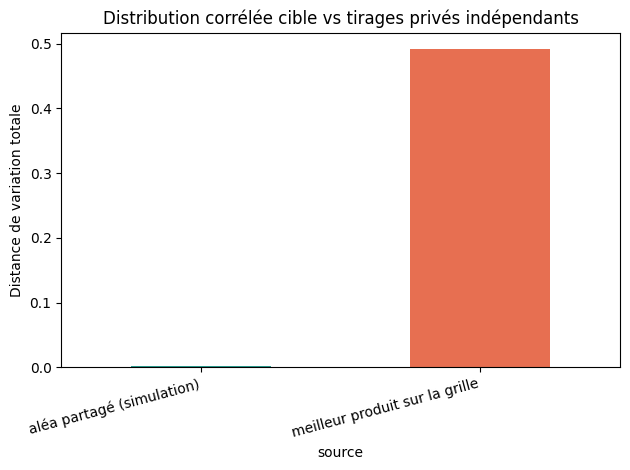

In [7]:
OUTCOMES_3 = list(product((0, 1), repeat=3))
TARGET = {outcome: 0.5 if outcome in {(0, 0, 0), (1, 1, 1)} else 0.0 for outcome in OUTCOMES_3}


def product_distribution(probabilities: tuple[float, float, float]) -> dict[tuple[int, ...], float]:
    return {
        outcome: float(np.prod([
            p if action == 1 else 1 - p
            for action, p in zip(outcome, probabilities)
        ]))
        for outcome in OUTCOMES_3
    }


def total_variation(left: dict, right: dict) -> float:
    return 0.5 * sum(abs(left[key] - right[key]) for key in left)


grid = np.linspace(0.0, 1.0, 21)
best_private = min(
    ((total_variation(TARGET, product_distribution(ps)), ps) for ps in product(grid, repeat=3)),
    key=lambda item: item[0],
)

rng_shared = np.random.default_rng(SEED)
shared_draws = rng_shared.integers(0, 2, size=20_000)
shared_empirical = Counter((int(bit),) * 3 for bit in shared_draws)
shared_distribution = {outcome: shared_empirical[outcome] / len(shared_draws) for outcome in OUTCOMES_3}

comparison_3p = pd.DataFrame([
    {"source": "aléa partagé (simulation)", "distance TV à la cible": total_variation(TARGET, shared_distribution)},
    {"source": "meilleur produit sur la grille", "distance TV à la cible": best_private[0]},
])
print(f"Meilleurs paramètres privés sur la grille : {best_private[1]}")
display(comparison_3p)

ax = comparison_3p.plot.bar(x="source", y="distance TV à la cible", legend=False, color=["#2a9d8f", "#e76f51"])
ax.set_ylabel("Distance de variation totale")
ax.set_title("Distribution corrélée cible vs tirages privés indépendants")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Lecture du résultat

La simulation avec pièce partagée approche la distribution cible `{000,111}` à l'erreur d'échantillonnage près. Même la meilleure distribution produit de la grille reste à distance strictement positive : des tirages privés indépendants ne peuvent pas produire exactement une alternance non dégénérée entre unanimité `0` et unanimité `1` sans créer aussi des issues désaccordées.

Ce cas rend visible une différence d'ensemble atteignable, mais il ne démontre pas le théorème 8. Dans le papier, les exemples 2–3 et 7 donnent un jeu des pirates plus discriminant et le théorème 8 impose une condition nécessaire aux équilibres de programmes simulationnistes sans aléa partagé.


## 6. Trois résultats à ne pas confondre

| Résultat | Cadre | Portée exacte |
|---|---|---|
| **Folk theorem de Tennenholtz** (2004 ; théorème 1 rappelé par Cooper et al., §2) | Jeux-programmes non corrélés, classe de programmes soumise à des restrictions | Les gains sont atteignables en équilibre ssi ils sont faisables sans corrélation et individuellement rationnels. Les constructions sont syntaxiquement fragiles. |
| **Folk theorem avec aléa partagé** (Cooper et al., corollaire 1, §3) | `εGroundedπBots` corrélés | Tout vecteur de gains faisable avec corrélation et strictement individuellement rationnel est atteignable par un équilibre, pour un `ε` commun approprié. |
| **Limite sans aléa partagé** (Cooper et al., théorème 8 et exemple 7, §5) | Programmes simulationnistes qui terminent et produisent indépendamment | Une condition nécessaire exclut notamment l'issue coopérative du jeu des pirates ; le folk theorem complet de Tennenholtz n'est donc pas atteignable dans cette classe. |

À cela s'ajoutent les propositions 1–2 (§4), qui caractérisent l'atteignabilité des `εGroundedπBots` non corrélés, et le théorème 7, positif pour les utilités additivement séparables.


### Exercice 3 — Quantifier la dette d'indépendance

Raffinez la grille des probabilités privées, puis comparez :

1. la distance minimale à la cible corrélée ;
2. la probabilité de désaccord entre les trois joueurs ;
3. l'utilité moyenne du jeu de coordination.

Formulez ensuite une conjecture sur la limite lorsque le pas de grille tend vers zéro, sans la présenter comme démontrée.


In [8]:
def dette_independance(pas: float):
    # TODO étudiant : raffiner la grille et retourner distance, désaccord et utilité.
    return None


mesure_raffinee = None  # TODO étudiant : appeler la fonction avec un pas plus fin.
print("Exercice 3 à compléter : dette d'indépendance et limite conjecturée.")


Exercice 3 à compléter : dette d'indépendance et limite conjecturée.


## 7. Conclusion et limites

Les mesures établissent trois faits **dans les modèles finis du notebook** :

1. l'inspection syntaxique peut distinguer arbitrairement deux adversaires comportementalement équivalents, tandis que la simulation bornée ne les distingue pas sur son échantillon ;
2. une réponse simulationniste punitive peut stabiliser la coopération du PD contre la bibliothèque de déviations testée ;
3. une pièce publique atteint une distribution d'équilibre corrélée à trois joueurs qu'aucune distribution produit privée de la grille ne reproduit.

Elles ne démontrent ni la terminaison presque sûre générale, ni les caractérisations d'équilibre, ni l'impossibilité du théorème 8. Ces claims appartiennent au papier primaire et sont cités avec leur cadre. La prochaine étape naturelle consiste à remplacer la bibliothèque finie de déviations par une classe de programmes formellement spécifiée, tout en conservant la distinction entre **mesure**, **preuve** et **absence de preuve**.

### Références

- Cooper, Oesterheld & Conitzer (2025), arXiv:2412.14570v2, §§2–5, algorithmes 1–2, corollaire 1, propositions 1–2, théorèmes 7–8.
- Oesterheld (2019), *Robust Program Equilibrium*.
- Tennenholtz (2004), *Program Equilibrium*.

[← GameTheory-06f](GameTheory-06f-Bounded-Proofs-Reasoning-Costs.ipynb) · [Retour à la série](README.md)
